In [ ]:
##Description:
##This project performs Exploratory Data Analysis (EDA) on Uber ride data
##to identify demand patterns and generate business insights.

In [79]:
##Import Libraries

In [80]:
import pandas as pd

In [81]:
import numpy as py
import seaborn as sns
import matplotlib.pyplot as plt

In [82]:
import os

In [83]:
##Load Data

In [84]:
os.listdir(r"C:\Users\dell\Downloads\Uber\Datasets")

['other-American_B01362.csv',
 'other-Carmel_B00256.csv',
 'other-Dial7_B00887.csv',
 'other-Diplo_B01196.csv',
 'other-Federal_02216.csv',
 'other-FHV-services_jan-aug-2015.csv',
 'other-Firstclass_B01536.csv',
 'other-Highclass_B01717.csv',
 'other-Lyft_B02510.csv',
 'other-Prestige_B01338.csv',
 'other-Skyline_B00111.csv',
 'Uber-Jan-Feb-FOIL.csv',
 'uber-raw-data-apr14.csv',
 'uber-raw-data-aug14.csv',
 'uber-raw-data-janjune-15.csv',
 'uber-raw-data-janjune-15_sample.csv',
 'uber-raw-data-jul14.csv',
 'uber-raw-data-jun14.csv',
 'uber-raw-data-may14.csv',
 'uber-raw-data-sep14.csv']

In [85]:
uber_15=pd.read_csv(r"C:\Users\dell\Downloads\Uber\Datasets/uber-raw-data-janjune-15_sample.csv")

In [127]:
uber_15

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID,month,Weekday,Day,Hour,Minute,Month
0,B02617,2015-05-02 21:43:00,B02764,237,May,Saturday,2,21,43,May
1,B02682,2015-01-20 19:52:59,B02682,231,January,Tuesday,20,19,52,January
2,B02617,2015-03-19 20:26:00,B02617,161,March,Thursday,19,20,26,March
3,B02764,2015-04-10 17:38:00,B02764,107,April,Friday,10,17,38,April
4,B02764,2015-03-23 07:03:00,B00111,140,March,Monday,23,7,3,March
...,...,...,...,...,...,...,...,...,...,...
99995,B02764,2015-04-13 16:12:00,B02764,234,April,Monday,13,16,12,April
99996,B02764,2015-03-06 21:32:00,B02764,24,March,Friday,6,21,32,March
99997,B02598,2015-03-19 19:56:00,B02598,17,March,Thursday,19,19,56,March
99998,B02682,2015-05-02 16:02:00,B02682,68,May,Saturday,2,16,2,May


In [87]:
uber_15.shape

(100000, 4)

In [129]:
##type of data
type(uber_15)

pandas.core.frame.DataFrame

In [89]:
##Data processing
uber_15.duplicated().sum()

np.int64(54)

In [90]:
uber_15.drop_duplicates(inplace=True)

In [91]:
uber_15.duplicated().sum()

np.int64(0)

In [92]:
uber_15.shape

(99946, 4)

In [93]:
uber_15.dtypes

Dispatching_base_num    object
Pickup_date             object
Affiliated_base_num     object
locationID               int64
dtype: object

In [94]:
uber_15.isnull().sum()

Dispatching_base_num       0
Pickup_date                0
Affiliated_base_num     1116
locationID                 0
dtype: int64

In [95]:
uber_15['Pickup_date'][0]

'2015-05-02 21:43:00'

In [96]:
type(uber_15['Pickup_date'][0])

str

In [97]:
##update pickupdate format
uber_15['Pickup_date']=pd.to_datetime(uber_15['Pickup_date'])

In [130]:
uber_15['Pickup_date'].dtype

dtype('<M8[ns]')

In [99]:
type(uber_15['Pickup_date'][0])

pandas._libs.tslibs.timestamps.Timestamp

In [100]:
uber_15.dtypes

Dispatching_base_num            object
Pickup_date             datetime64[ns]
Affiliated_base_num             object
locationID                       int64
dtype: object

In [101]:
##which month has highest pickups

In [132]:
monthly_demand = uber_15['Month'].value_counts()

print(monthly_demand)

Month
June        19620
May         18660
April       15982
March       15969
February    15896
January     13819
Name: count, dtype: int64


In [133]:
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

monthly_demand = monthly_demand.reindex(month_order)

In [135]:
max_month = monthly_demand.idxmax()
max_value = monthly_demand.max()

print(f"Maximum pickups in: {max_month} ({max_value} rides)")

Maximum pickups in: June (19620.0 rides)


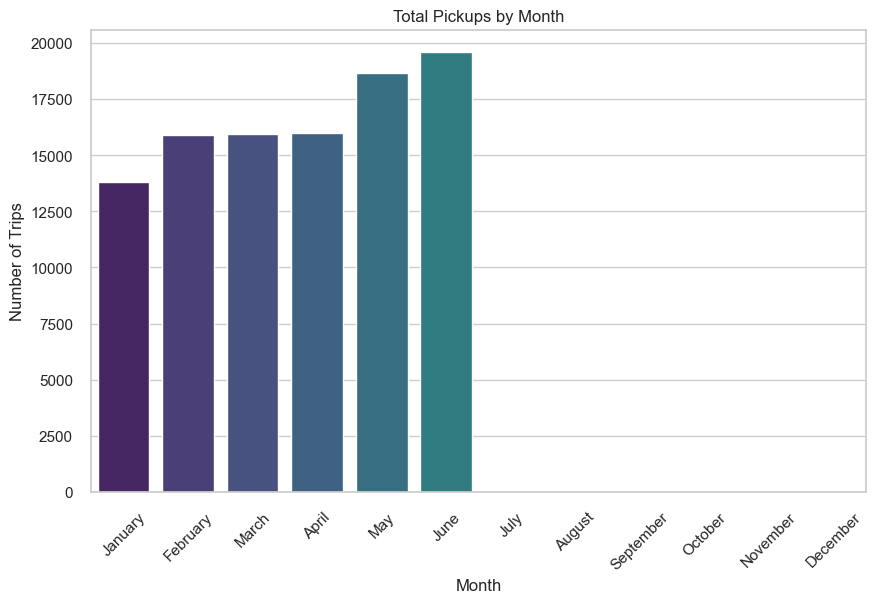

In [136]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    x=monthly_demand.index,
    y=monthly_demand.values,
    hue=monthly_demand.index,
    palette='viridis',
    legend=False
)

plt.title("Total Pickups by Month")
plt.xlabel("Month")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.show()

In [137]:
##“The analysis shows that [Month Name] has the highest number of pickups, indicating a seasonal spike in demand.
##This could be driven by factors such as weather conditions, holidays, or increased travel activity during that period.”

In [ ]:
##Demand by Hour (Peak Time Analysis)

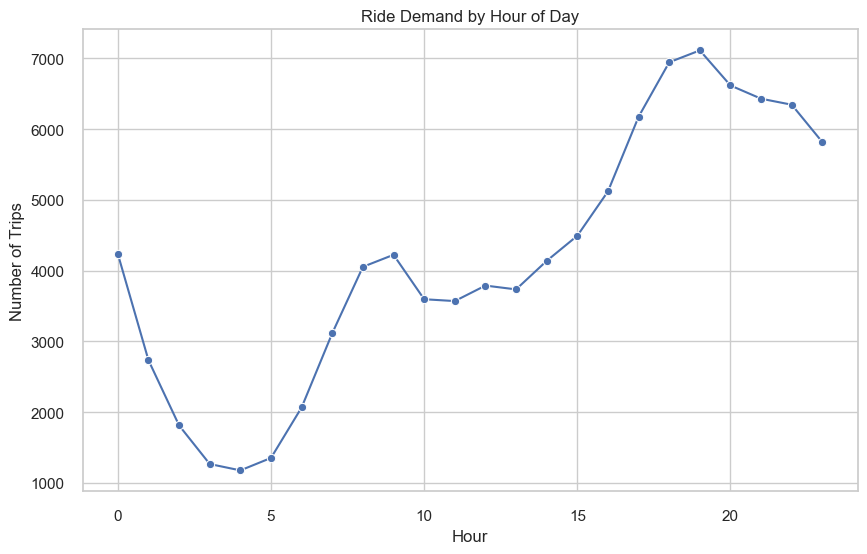

In [142]:
sns.set_theme(style="whitegrid")

# Count rides per hour
hourly_demand = uber_15['Hour'].value_counts().sort_index()

plt.figure(figsize=(10,6))

sns.lineplot(x=hourly_demand.index, y=hourly_demand.values, marker='o')

plt.title("Ride Demand by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Trips")
plt.show()

In [ ]:
##Ride demand peaks during morning (7–10 AM) and evening (5–9 PM), indicating strong commute-driven usage.

In [ ]:
##Demand by Weekday (Daily Pattern)

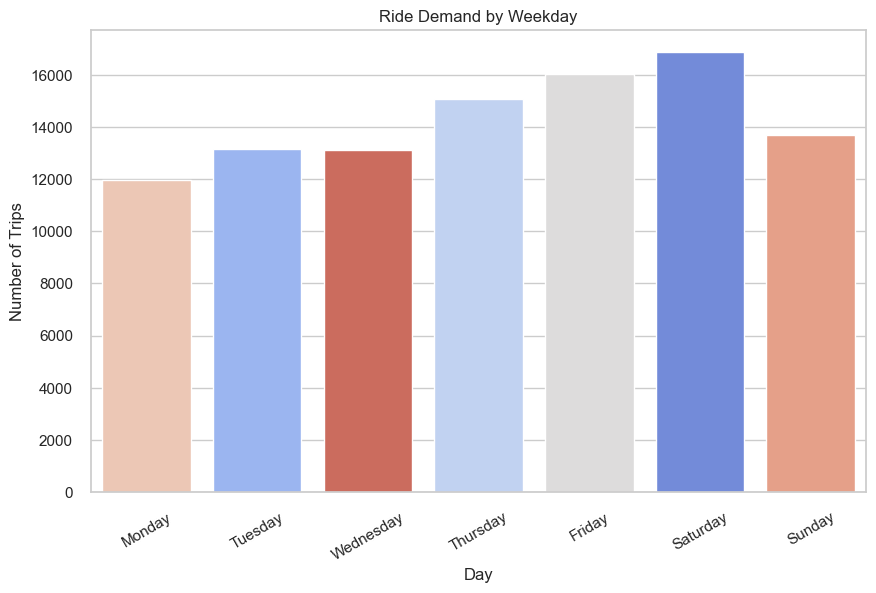

In [143]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

plt.figure(figsize=(10,6))

sns.countplot(
    data=uber_15,
    x='Weekday',
    hue='Weekday',
    order=order,
    palette='coolwarm',
    legend=False
)

plt.title("Ride Demand by Weekday")
plt.xlabel("Day")
plt.ylabel("Number of Trips")
plt.xticks(rotation=30)
plt.show()

In [ ]:
##Weekdays show steady demand due to office commutes, while weekends often show increased or shifted demand patterns driven by leisure activities.

In [ ]:
##Heatmap (Hour vs Day – MOST IMPORTANT)

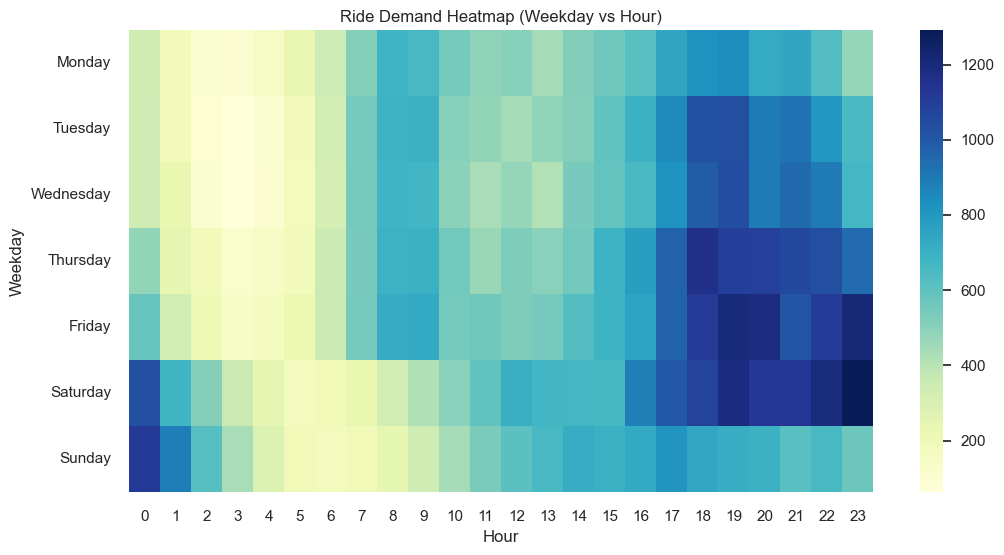

In [144]:
pivot = pd.crosstab(uber_15['Weekday'], uber_15['Hour'])

pivot = pivot.reindex(order)

plt.figure(figsize=(12,6))

sns.heatmap(pivot, cmap='YlGnBu')

plt.title("Ride Demand Heatmap (Weekday vs Hour)")
plt.xlabel("Hour")
plt.ylabel("Weekday")
plt.show()

In [ ]:
##The heatmap reveals:

Weekday peaks during commute hours
Weekend late-night activity
Clear behavioral segmentation between workdays and leisure days

In [ ]:
##“Which hours (or days) contribute to 80% of total rides?”

In [145]:
# Step 1: Count rides per hour
hourly = uber_15['Hour'].value_counts().sort_values(ascending=False)

# Step 2: Convert to DataFrame
pareto = hourly.reset_index()
pareto.columns = ['Hour', 'Trips']

# Step 3: Calculate cumulative %
pareto['Cumulative %'] = pareto['Trips'].cumsum() / pareto['Trips'].sum() * 100

print(pareto.head())

   Hour  Trips  Cumulative %
0    19   7114      7.117844
1    18   6946     14.067597
2    20   6618     20.689172
3    21   6431     27.123647
4    22   6346     33.473075


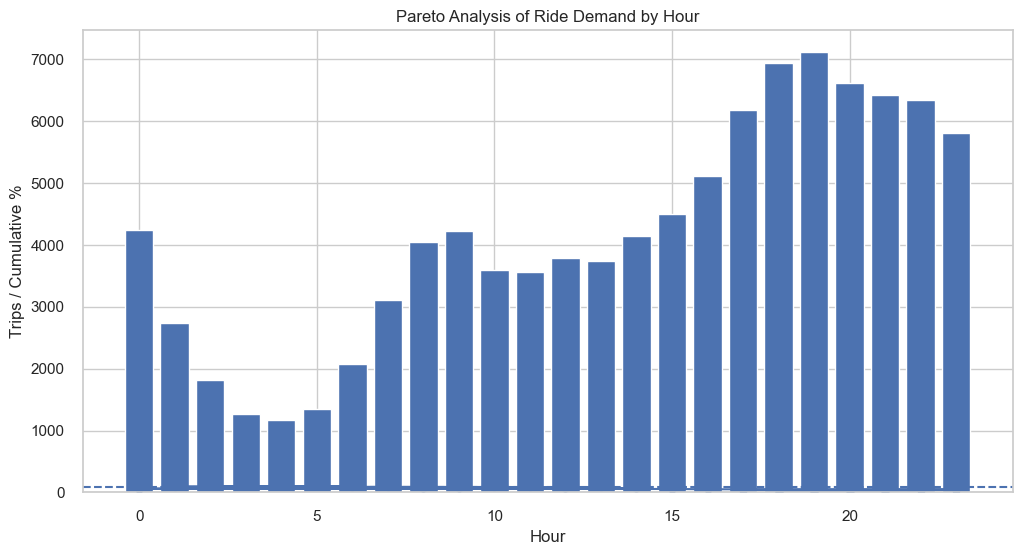

In [146]:
plt.figure(figsize=(12,6))

# Bar chart
plt.bar(pareto['Hour'], pareto['Trips'])

# Line chart (cumulative %)
plt.plot(pareto['Hour'], pareto['Cumulative %'], marker='o')

# 80% reference line
plt.axhline(80, linestyle='--')

plt.title("Pareto Analysis of Ride Demand by Hour")
plt.xlabel("Hour")
plt.ylabel("Trips / Cumulative %")
plt.show()

In [147]:
####“Pareto analysis reveals that a limited number of hours contribute to the majority of ride demand. These peak hours account for nearly 
##80% of total trips,indicating that optimizing driver allocation during these periods can significantly improve efficiency and revenue.”

In [153]:
####Analysing which base number has the most active vehicles


In [154]:
##Identify Airport-Heavy Bases (Proxy Analysis)

In [152]:
uber_15['dispatching_base_number'].value_counts()

KeyError: 'dispatching_base_number'